In [24]:
import pandas as pd
import numpy as np
import os
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pylab as plt
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.preprocessing import MinMaxScaler

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# Load the dataset using the absolute path
CollegeAdmissionData = pd.read_csv('/content/drive/MyDrive/GitHub_Files/Analysis/CollegeAdmissions_Data.csv')

# Print the shape
print(CollegeAdmissionData.shape)

(1946, 81)


In [27]:
print(CollegeAdmissionData.shape)
key_cols = [
    "par_income_bin","par_income_lab","attend","rel_attend","rel_apply","rel_att_cond_app",
    "attend_sat","rel_apply_sat","rel_attend_sat",
    "attend_instate","attend_oostate",
    "public","flagship","tier","tier_name","test_band_tier","name"]
[c for c in key_cols if c in CollegeAdmissionData.columns]

(1946, 81)


['par_income_bin',
 'par_income_lab',
 'attend',
 'rel_attend',
 'rel_apply',
 'rel_att_cond_app',
 'attend_sat',
 'rel_apply_sat',
 'rel_attend_sat',
 'attend_instate',
 'attend_oostate',
 'public',
 'flagship',
 'tier',
 'tier_name',
 'test_band_tier',
 'name']

In [28]:
import os

PLOTS_DIR  = os.path.join(OUT_DIR, "plots")
TABLES_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

print("PLOTS_DIR:", PLOTS_DIR)
print("TABLES_DIR:", TABLES_DIR)

PLOTS_DIR: /content/drive/MyDrive/GitHub_Files/Analysis/plots
TABLES_DIR: /content/drive/MyDrive/GitHub_Files/Analysis/tables


In [29]:
d = CollegeAdmissionData.copy()

num_cols = [
    "par_income_bin","attend","rel_attend","rel_apply","rel_att_cond_app",
    "attend_sat","rel_apply_sat","rel_attend_sat",
    "attend_instate","attend_oostate"
]
for c in num_cols:
    if c in d.columns:
        d[c] = pd.to_numeric(d[c], errors="coerce")

def to_fraction(s):
    if s.notna().sum() == 0:
        return s
    return s/100.0 if s.median() > 1 else s

for c in ["attend","attend_sat","attend_instate","attend_oostate",
          "rel_attend","rel_apply","rel_att_cond_app",
          "rel_apply_sat","rel_attend_sat"]:
    if c in d.columns:
        d[c] = to_fraction(d[c])

d_core = d.dropna(subset=["par_income_bin","attend"]).copy()
print("usable rows:", d_core.shape[0])


usable rows: 1944


In [30]:
att_income = (d_core.groupby("par_income_bin", as_index=False)["attend"].mean().sort_values("par_income_bin"))
att_income.head()


,par_income_bin,attend
0,10.0,0.003666
1,30.0,0.003657
2,50.0,0.003505
3,65.0,0.003338
4,75.0,0.003412


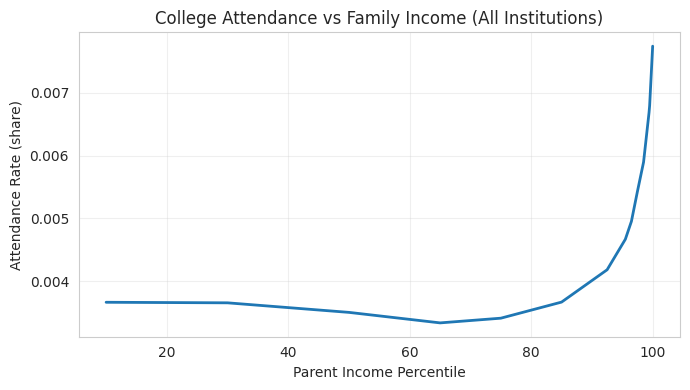

In [31]:
plt.figure(figsize=(7,4))
plt.plot(att_income["par_income_bin"], att_income["attend"], linewidth=2)
plt.xlabel("Parent Income Percentile")
plt.ylabel("Attendance Rate (share)")
plt.title("College Attendance vs Family Income (All Institutions)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "attend_vs_income_overall.png"), dpi=220)
plt.show()

att_income.to_csv(os.path.join(TABLES_DIR, "attendance_by_income_overall.csv"), index=False)


Very low-income students often receive strong financial aid and support programs, so their attendance rate is not the absolute lowest. Families in the middle, around the 30th to 50th percentile, can actually be in a tougher spot: they are too rich for full aid but still do not have enough money to pay easily, so their attendance rate can dip a little. For high-income families at the top, money and information are less of a barrier, so attendance jumps up sharply. That is why the line bends down slightly in the middle, even though income itself keeps going up.

In [32]:
# Look at the mid-income range and see where attendance falls as income rises
mid = att_income[(att_income["par_income_bin"] >= 20) &
                 (att_income["par_income_bin"] <= 60)].copy()

mid["delta_attend"] = mid["attend"].diff()

print("Changes in attendance between 20th and 60th income percentile:")
print(mid[["par_income_bin", "attend", "delta_attend"]])

print("\nBins where attendance goes DOWN when income goes UP:")
print(mid[mid["delta_attend"] < 0][["par_income_bin", "attend", "delta_attend"]])

Changes in attendance between 20th and 60th income percentile:
   par_income_bin    attend  delta_attend
1            30.0  0.003657           NaN
2            50.0  0.003505     -0.000152

Bins where attendance goes DOWN when income goes UP:
   par_income_bin    attend  delta_attend
2            50.0  0.003505     -0.000152


The numbers show that in the middle of the income distribution, around the 50th percentile, college attendance drops a little even though income is still going up. Before and after that point, attendance is mostly flat or rising. This small drop in the middle explains why the line in our graph bends down slightly before it rises again for the highest-income families.

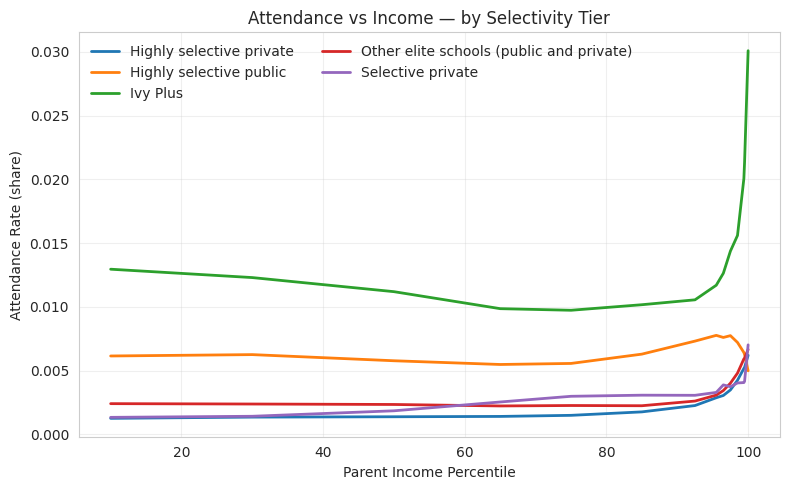

In [33]:
if "tier_name" in d_core.columns:
    att_by_tier = (
        d_core.groupby(["tier_name","par_income_bin"], as_index=False)["attend"]
        .mean())

    top_tiers = att_by_tier["tier_name"].value_counts().index.tolist()[:5]

    plt.figure(figsize=(8,5))
    for t in top_tiers:
        sub = att_by_tier[att_by_tier["tier_name"]==t].sort_values("par_income_bin")
        plt.plot(sub["par_income_bin"], sub["attend"], linewidth=2, label=t)
    plt.xlabel("Parent Income Percentile")
    plt.ylabel("Attendance Rate (share)")
    plt.title("Attendance vs Income — by Selectivity Tier")
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "attend_vs_income_by_tier.png"), dpi=220)
    plt.show()

    att_by_tier.to_csv(os.path.join(TABLES_DIR, "attendance_by_income_tier.csv"), index=False)
else:
    print("tier_name not found — skipping tier plot.")


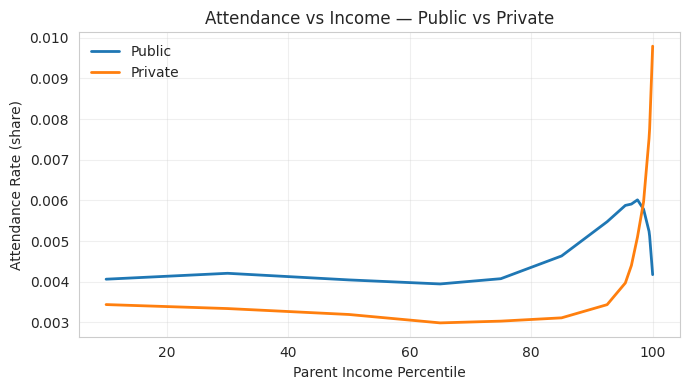

In [34]:
if "public" in d_core.columns:
    d_core["sector"] = d_core["public"].map({
        1: "Public",
        0: "Private",
        "Public": "Public",
        "Private": "Private"
    }).fillna("Private")

    att_by_sector = (d_core.groupby(["sector","par_income_bin"], as_index=False)["attend"].mean())

    plt.figure(figsize=(7,4))
    for s in ["Public","Private"]:
        sub = att_by_sector[att_by_sector["sector"]==s].sort_values("par_income_bin")
        plt.plot(sub["par_income_bin"], sub["attend"], linewidth=2, label=s)

    plt.xlabel("Parent Income Percentile")
    plt.ylabel("Attendance Rate (share)")
    plt.title("Attendance vs Income — Public vs Private")
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "attend_vs_income_public_private.png"), dpi=220)
    plt.show()

    att_by_sector.to_csv(os.path.join(TABLES_DIR, "attendance_by_income_sector.csv"), index=False)
else:
    print("public not found — skipping public/private plot.")


In [35]:
def inc_bucket(p):
    if p <= 20: return "Bottom 0–20"
    if p >= 80: return "Top 80–100"
    return "Middle"

d_core["inc_bucket"] = d_core["par_income_bin"].apply(inc_bucket)

gap_overall_tbl = (d_core.groupby("inc_bucket", as_index=False)["attend"].mean().pivot_table(index=None, columns="inc_bucket", values="attend"))
gap_overall_tbl["Gap_TopMinusBottom"] = (gap_overall_tbl["Top 80–100"] - gap_overall_tbl["Bottom 0–20"])

print("Headline gap (Top 80–100 minus Bottom 0–20):")
display(gap_overall_tbl.round(3))

gap_overall_tbl.to_csv(
    os.path.join(TABLES_DIR, "gap_overall_top_minus_bottom.csv"),
    index=False)

Headline gap (Top 80–100 minus Bottom 0–20):


inc_bucket,Bottom 0–20,Middle,Top 80–100,Gap_TopMinusBottom
attend,0.004,0.003,0.006,0.002


In [36]:
if "tier_name" in d_core.columns:
    gap_by_tier_tbl = (d_core.groupby(["tier_name","inc_bucket"], as_index=False)["attend"].mean().pivot_table(index="tier_name", columns="inc_bucket", values="attend"))
    gap_by_tier_tbl["Gap_TopMinusBottom"] = (gap_by_tier_tbl["Top 80–100"] - gap_by_tier_tbl["Bottom 0–20"])
    gap_by_tier_tbl = gap_by_tier_tbl.sort_values("Gap_TopMinusBottom", ascending=False)

    print("Largest Top–Bottom gaps by tier (top 8):")
    display(gap_by_tier_tbl.head(8).round(3))

    gap_by_tier_tbl.to_csv(os.path.join(TABLES_DIR, "gap_by_tier_top_minus_bottom.csv"))
else:
    print("tier_name not found — skipping gap-by-tier table.")


Largest Top–Bottom gaps by tier (top 8):


inc_bucket,Bottom 0–20,Middle,Top 80–100,Gap_TopMinusBottom
tier_name,,,,
Ivy Plus,0.013,0.011,0.016,0.003
Selective private,0.001,0.002,0.004,0.003
Highly selective private,0.001,0.001,0.004,0.003
Other elite schools (public and private),0.002,0.002,0.004,0.002
Selective public,0.002,0.003,0.004,0.002
Highly selective public,0.006,0.006,0.007,0.001


In [37]:
import statsmodels.formula.api as smf

m1 = smf.ols("attend ~ par_income_bin", data=d_core).fit(cov_type="HC1")
print("Overall slope (Δ attendance per income percentile):",
      round(m1.params.get("par_income_bin", float("nan")), 4))
m1.summary().tables[1]


Overall slope (Δ attendance per income percentile): 0.0


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,0.0023,0.000,7.413,0.000,0.002,0.003
par_income_bin,3.246e-05,4.08e-06,7.963,0.000,2.45e-05,4.04e-05


In [38]:
print(d_core[['par_income_bin','attend','public']].shape)
print(d_core['public'].value_counts(dropna=False))

d_pub = d_core.copy()
d_pub['public'] = pd.to_numeric(d_pub['public'], errors='coerce')
d_pub = d_pub[d_pub['public'].isin([0, 1])]
d_pub = d_pub.dropna(subset=['par_income_bin','attend','public'])

print("usable rows for interaction:", d_pub.shape[0])
print("class counts:\n", d_pub['public'].value_counts())

if (len(d_pub) > 0) and (d_pub['public'].nunique() == 2):
    m2 = smf.ols("attend ~ par_income_bin * public", data=d_pub).fit(cov_type="HC1")
    print("\n=== Interaction model (income * public) — key params ===")
    print(m2.params.round(4))
    m2.summary().tables[1]
else:
    print("Not enough variation in 'public' to fit interaction. "
          "Falling back to separate simple slopes:")
    for label, sub in d_pub.groupby('public'):
        if len(sub) >= 10:
            m_sep = smf.ols("attend ~ par_income_bin", data=sub).fit(cov_type="HC1")
            print(f"public={label} slope:",
                  round(m_sep.params.get('par_income_bin', float('nan')), 4))


(1944, 3)
public
Private    1231
Public      713
Name: count, dtype: int64
usable rows for interaction: 0
class counts:
 Series([], Name: count, dtype: int64)
Not enough variation in 'public' to fit interaction. Falling back to separate simple slopes:


In [39]:
slope = m1.params.get("par_income_bin", float("nan"))
print(f"[Script] Each +1 income percentile ↗ attendance by {slope:.4f} (overall).")

print("\n[Script] Headline gap (Top 80–100 minus Bottom 0–20):")
display(gap_overall_tbl.round(3))

if "tier_name" in d_core.columns:
    print("\n[Script] Tiers with the largest gaps (top 5):")
    display(gap_by_tier_tbl.head(5).round(3))

[Script] Each +1 income percentile ↗ attendance by 0.0000 (overall).

[Script] Headline gap (Top 80–100 minus Bottom 0–20):


inc_bucket,Bottom 0–20,Middle,Top 80–100,Gap_TopMinusBottom
attend,0.004,0.003,0.006,0.002



[Script] Tiers with the largest gaps (top 5):


inc_bucket,Bottom 0–20,Middle,Top 80–100,Gap_TopMinusBottom
tier_name,,,,
Ivy Plus,0.013,0.011,0.016,0.003
Selective private,0.001,0.002,0.004,0.003
Highly selective private,0.001,0.001,0.004,0.003
Other elite schools (public and private),0.002,0.002,0.004,0.002
Selective public,0.002,0.003,0.004,0.002
